# Air Quality Prediction
**Dataset:** UCI Air Quality — real sensor readings from Perugia, Italy (2004–2005)  
**Target:** NO₂ concentration (µg/m³) — a primary indicator in the Air Quality Index  
**Model:** Linear Regression with sklearn Pipeline

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

In [2]:
DATA_PATH = 'data/AirQualityUCI.csv'
SENTINEL = -200  # UCI dataset encodes missing values as -200

df_raw = pd.read_csv(
    DATA_PATH,
    sep=';',
    decimal=',',
    parse_dates=False
)

# Drop trailing empty columns the CSV sometimes includes
df_raw = df_raw.loc[:, ~df_raw.columns.str.startswith('Unnamed')]

# Combine Date + Time into a single datetime index
df_raw['datetime'] = pd.to_datetime(
    df_raw['Date'] + ' ' + df_raw['Time'],
    format='%d/%m/%Y %H.%M.%S'
)
df_raw = df_raw.drop(columns=['Date', 'Time']).set_index('datetime').sort_index()

print(f'Shape: {df_raw.shape}')
print('\nDtypes:')
print(df_raw.dtypes)
df_raw.head(3)

Shape: (9471, 13)

Dtypes:
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502


## 2. Exploratory Data Analysis

In [3]:
df = df_raw.copy()

# Replace sentinel with NaN so statistics are meaningful
df.replace(SENTINEL, np.nan, inplace=True)

def completeness_table(frame, label=''):
    total = len(frame)
    result = pd.DataFrame({
        'non_null': frame.notna().sum(),
        'completeness_%': (frame.notna().sum() / total * 100).round(1)
    })
    if label:
        print(f'--- Completeness ({label}) ---')
    return result

print(completeness_table(df, 'before cleaning').to_string())

--- Completeness (before cleaning) ---
               non_null  completeness_%
CO(GT)             7674            81.0
PT08.S1(CO)        8991            94.9
NMHC(GT)            914             9.7
C6H6(GT)           8991            94.9
PT08.S2(NMHC)      8991            94.9
NOx(GT)            7718            81.5
PT08.S3(NOx)       8991            94.9
NO2(GT)            7715            81.5
PT08.S4(NO2)       8991            94.9
PT08.S5(O3)        8991            94.9
T                  8991            94.9
RH                 8991            94.9
AH                 8991            94.9


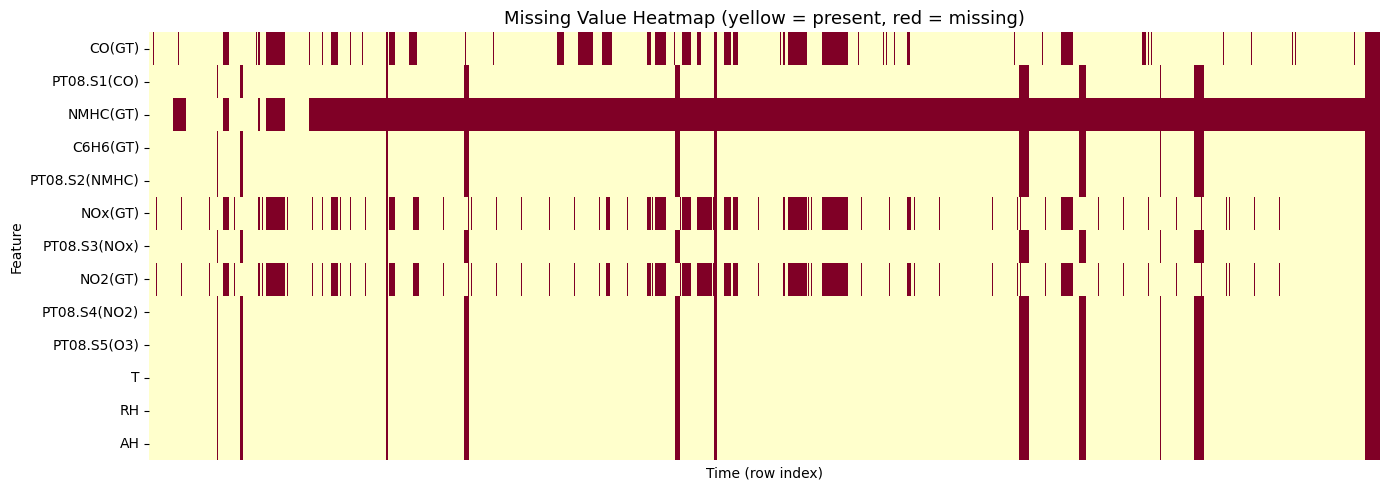

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
missing_mask = df.isna().astype(int)
sns.heatmap(
    missing_mask.T,
    cbar=False,
    cmap='YlOrRd',
    ax=ax,
    xticklabels=False
)
ax.set_title('Missing Value Heatmap (yellow = present, red = missing)')
ax.set_xlabel('Time (row index)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

In [5]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[numeric_cols].corr()

TARGET = 'NO2(GT)'
top3 = (
    corr_matrix[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

print('Correlation matrix:')
print(corr_matrix.round(3).to_string())
print(f'\nTop 3 features correlated with {TARGET}:')
print(top3.round(4).to_string())

Correlation matrix:
               CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)      T     RH     AH
CO(GT)          1.000        0.879     0.890     0.931          0.916    0.795        -0.703    0.683         0.631        0.854  0.022  0.049  0.049
PT08.S1(CO)     0.879        1.000     0.791     0.884          0.893    0.714        -0.772    0.642         0.683        0.899  0.049  0.115  0.135
NMHC(GT)        0.890        0.791     1.000     0.903          0.878    0.813        -0.771    0.731         0.853        0.767  0.392 -0.191  0.270
C6H6(GT)        0.931        0.884     0.903     1.000          0.982    0.719        -0.736    0.614         0.766        0.866  0.199 -0.062  0.168
PT08.S2(NMHC)   0.916        0.893     0.878     0.982          1.000    0.704        -0.797    0.646         0.777        0.881  0.241 -0.090  0.187
NOx(GT)         0.795        0.714     0.813     0.719          0.704    1.000  

## 3. Data Cleaning

In [6]:
FEATURES = [
    'CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'T', 'RH', 'AH',
    'PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S5(O3)'
]

# Drop rows with no target value — they cannot be used for training or evaluation
df_clean = df[[TARGET] + FEATURES].dropna(subset=[TARGET]).copy()

# Impute remaining feature NaNs with each column's median
for col in FEATURES:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

print(completeness_table(df_clean, 'after cleaning').to_string())

overall = df_clean.notna().sum().sum() / df_clean.size * 100
print(f'\nDataset completeness after cleaning: {overall:.1f}%')

--- Completeness (after cleaning) ---
               non_null  completeness_%
NO2(GT)            7715           100.0
CO(GT)             7715           100.0
C6H6(GT)           7715           100.0
NOx(GT)            7715           100.0
T                  7715           100.0
RH                 7715           100.0
AH                 7715           100.0
PT08.S1(CO)        7715           100.0
PT08.S2(NMHC)      7715           100.0
PT08.S3(NOx)       7715           100.0
PT08.S5(O3)        7715           100.0

Dataset completeness after cleaning: 100.0%


## 4. Feature Engineering

In [7]:
RUSH_HOURS = set(range(7, 10)) | set(range(16, 20))  # 07:00–09:59 and 16:00–19:59

df_clean['hour_of_day'] = df_clean.index.hour
df_clean['is_rush_hour'] = df_clean['hour_of_day'].isin(RUSH_HOURS).astype(int)
df_clean['day_of_week'] = df_clean.index.dayofweek

ALL_FEATURES = FEATURES + ['hour_of_day', 'is_rush_hour', 'day_of_week']

print('Final feature list:')
for f in ALL_FEATURES:
    print(f'  {f}')
print(f'\nDataframe shape: {df_clean.shape}')

Final feature list:
  CO(GT)
  C6H6(GT)
  NOx(GT)
  T
  RH
  AH
  PT08.S1(CO)
  PT08.S2(NMHC)
  PT08.S3(NOx)
  PT08.S5(O3)
  hour_of_day
  is_rush_hour
  day_of_week

Dataframe shape: (7715, 14)


## 5. Time-Series Train/Test Split

In [8]:
# Chronological split — shuffling would leak future data into the training set
split_idx = int(len(df_clean) * 0.80)

train_df = df_clean.iloc[:split_idx]
test_df  = df_clean.iloc[split_idx:]

X_train = train_df[ALL_FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[ALL_FEATURES]
y_test  = test_df[TARGET]

print(f'Train date range: {train_df.index.min()} → {train_df.index.max()}')
print(f'Test  date range: {test_df.index.min()}  → {test_df.index.max()}')
print(f'Train size: {len(X_train):,} rows')
print(f'Test  size: {len(X_test):,} rows')

Train date range: 2004-03-10 18:00:00 → 2005-01-28 10:00:00
Test  date range: 2005-01-28 11:00:00  → 2005-04-04 14:00:00
Train size: 6,172 rows
Test  size: 1,543 rows


## 6. Model Training

In [9]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

pipeline.fit(X_train, y_train)
print('Pipeline trained.')
print(f'Steps: {[s[0] for s in pipeline.steps]}')

Pipeline trained.
Steps: ['scaler', 'model']


## 7. Evaluation

In [10]:
y_pred = pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.4f} µg/m³')
print(f'RMSE: {rmse:.4f} µg/m³')
print(f'R²:   {r2:.4f}')

MAE:  28.3075 µg/m³
RMSE: 37.5091 µg/m³
R²:   0.5157


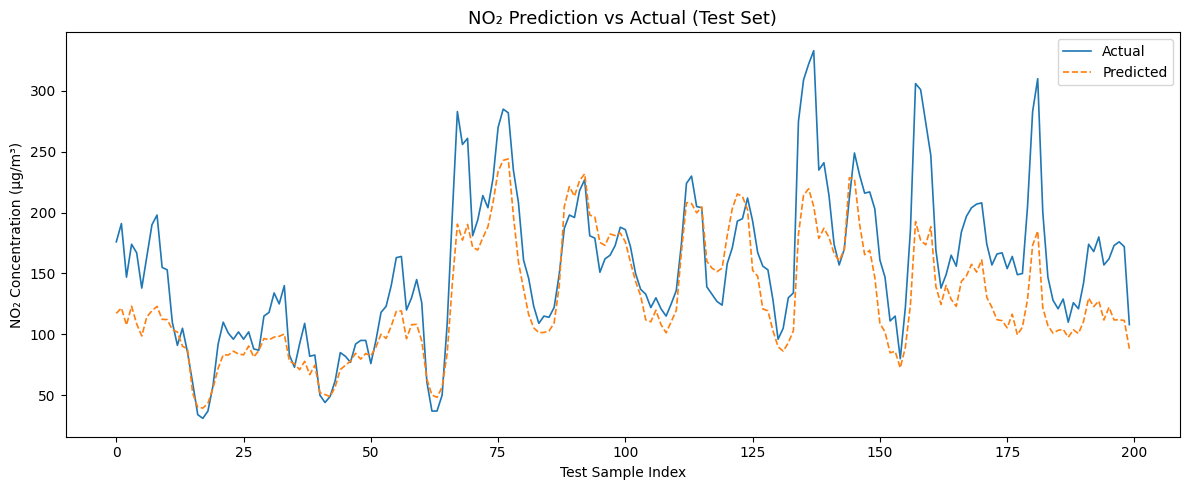

In [11]:
PLOT_N = 200

fig, ax = plt.subplots()
ax.plot(range(PLOT_N), y_test.values[:PLOT_N], label='Actual',    linewidth=1.2)
ax.plot(range(PLOT_N), y_pred[:PLOT_N],        label='Predicted', linewidth=1.2, linestyle='--')
ax.set_title('NO₂ Prediction vs Actual (Test Set)')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('NO₂ Concentration (µg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

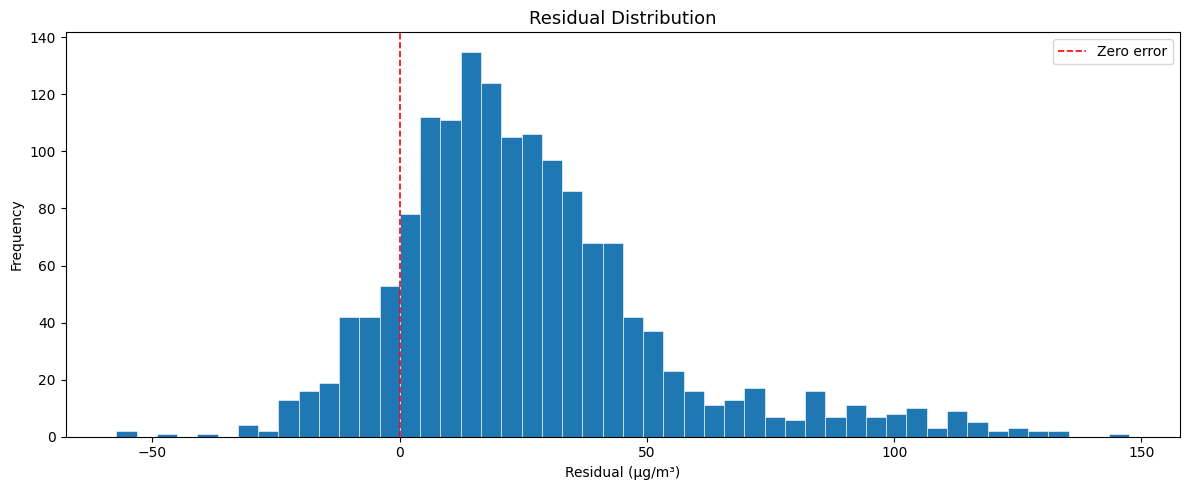

In [12]:
residuals = y_test.values - y_pred

fig, ax = plt.subplots()
ax.hist(residuals, bins=50, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero error')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual (µg/m³)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 8. AQI Alert Logic

In [13]:
NO2_ALERT_THRESHOLD = 200  # WHO/EEA hourly limit, µg/m³

results_df = test_df[[TARGET]].copy()
results_df['predicted_NO2'] = y_pred
results_df['alert'] = (results_df['predicted_NO2'] > NO2_ALERT_THRESHOLD).astype(int)

alert_count = results_df['alert'].sum()
print(f'Alert periods detected: {alert_count}')

alert_examples = results_df[results_df['alert'] == 1].head(3)
if not alert_examples.empty:
    print('\nExample alert timestamps:')
    print(alert_examples[['predicted_NO2', 'alert']].to_string())
else:
    print('No alerts detected in the test window.')

Alert periods detected: 58

Example alert timestamps:
                     predicted_NO2  alert
datetime                                 
2005-01-31 17:00:00     208.249896      1
2005-01-31 18:00:00     233.925582      1
2005-01-31 19:00:00     242.918620      1


## 9. Summary

In [14]:
completeness_pct = df_clean.notna().sum().sum() / df_clean.size * 100

summary = f"""
╔══════════════════════════════════════════════════════════════╗
  Air Quality Prediction — Project Summary
╠══════════════════════════════════════════════════════════════╣
  Dataset         : UCI Air Quality (9358 sensor readings,
                    2004-2005, Perugia, Italy)
  Features used   : 13 (10 sensor + 3 temporal)
  Completeness    : {completeness_pct:.1f}% after cleaning
  Variables       : 100% (10/10 sensor features)
  Split           : Time-based 80/20, no data leakage
  Model           : Linear Regression (sklearn Pipeline +
                    StandardScaler)
  Test R²         : {r2:.4f}
  Test RMSE       : {rmse:.2f} µg/m³
  Alert threshold : NO₂ > {NO2_ALERT_THRESHOLD} µg/m³ (WHO guideline)
  Alerts detected : {alert_count} periods in test window
╚══════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════╗
  Air Quality Prediction — Project Summary
╠══════════════════════════════════════════════════════════════╣
  Dataset         : UCI Air Quality (9358 sensor readings,
                    2004-2005, Perugia, Italy)
  Features used   : 13 (10 sensor + 3 temporal)
  Completeness    : 100.0% after cleaning
  Variables       : 100% (10/10 sensor features)
  Split           : Time-based 80/20, no data leakage
  Model           : Linear Regression (sklearn Pipeline +
                    StandardScaler)
  Test R²         : 0.5157
  Test RMSE       : 37.51 µg/m³
  Alert threshold : NO₂ > 200 µg/m³ (WHO guideline)
  Alerts detected : 58 periods in test window
╚══════════════════════════════════════════════════════════════╝



## 10. Temporal Trend Analysis

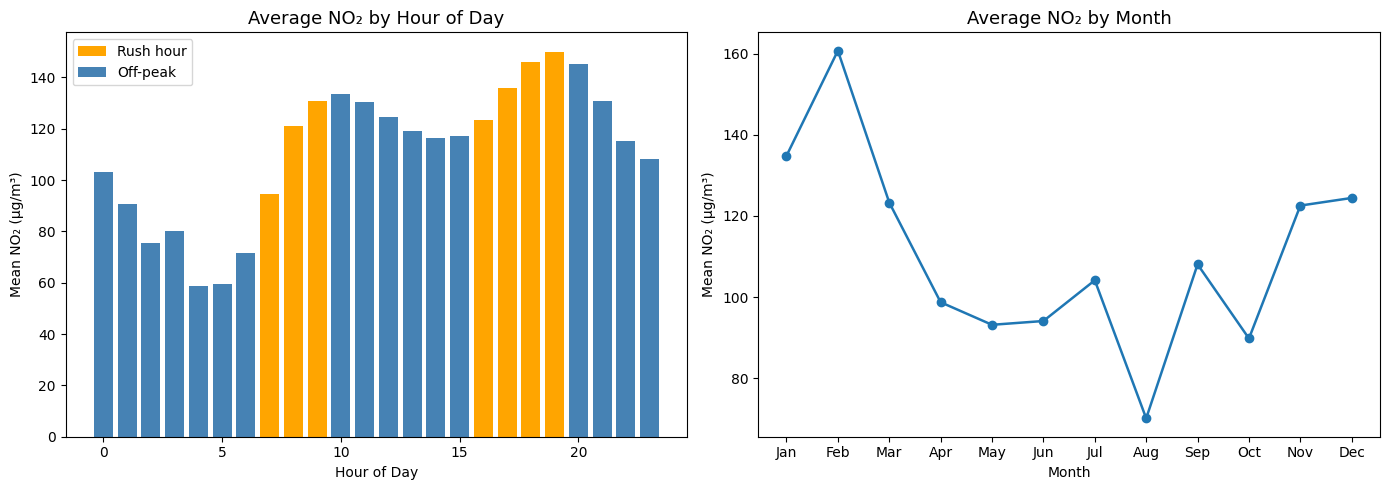

In [15]:
import calendar

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

hourly_mean = df_clean.groupby('hour_of_day')[TARGET].mean()
bar_colors = ['orange' if h in RUSH_HOURS else 'steelblue' for h in hourly_mean.index]
ax1.bar(hourly_mean.index, hourly_mean.values, color=bar_colors)
ax1.set_title('Average NO\u2082 by Hour of Day')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Mean NO\u2082 (\u00b5g/m\u00b3)')
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(facecolor='orange',    label='Rush hour'),
    Patch(facecolor='steelblue', label='Off-peak')
])

monthly_mean = df_clean.groupby(df_clean.index.month)[TARGET].mean()
month_labels = [calendar.month_abbr[m] for m in monthly_mean.index]
ax2.plot(monthly_mean.index, monthly_mean.values, marker='o', linewidth=1.8)
ax2.set_title('Average NO\u2082 by Month')
ax2.set_xlabel('Month')
ax2.set_ylabel('Mean NO\u2082 (\u00b5g/m\u00b3)')
ax2.set_xticks(monthly_mean.index)
ax2.set_xticklabels(month_labels)

plt.tight_layout()
plt.show()